In [14]:
import sys

sys.path.append("..")

import seaborn as sns
import matplotlib.pyplot as plt
from src.data_preprocessing import load_data, drop_duplicates

In [15]:
df = load_data("../data/raw/IMDB Dataset.csv")
df.head()

Data loaded successfully from (../data/raw/IMDB Dataset.csv)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [16]:
df.shape

(50000, 2)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [18]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [19]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(418)

In [21]:
duplicated_rows =df[df.duplicated(keep=False)]
duplicated_rows.head(20)

,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
84,"We brought this film as a joke for a friend, a...",negative
140,"Before I begin, let me get something off my ch...",negative
219,Ed Wood rides again. The fact that this movie ...,negative
245,I have seen this film at least 100 times and I...,positive
480,From director Barbet Schroder (Reversal of For...,negative
513,"The story and the show were good, but it was r...",negative
636,I rented this thinking it would be pretty good...,negative
638,This movie has everything typical horror movie...,positive
701,I Enjoyed Watching This Well Acted Movie Very ...,positive


In [22]:
# Check if the duplicated rows are identical

df[
    (df['review'] == df.loc[42, 'review']) &
    (df['sentiment'] == df.loc[42, 'sentiment'])
]

,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
25088,"Of all the films I have seen, this one, The Ra...",negative


In [23]:
df = drop_duplicates(df)

Dropped 418 duplicate rows.


In [24]:
df.describe()

,review,sentiment
count,49582,49582
unique,49582,2
top,No one expects the Star Trek movies to be high...,positive
freq,1,24884


Text(0, 0.5, 'Count')

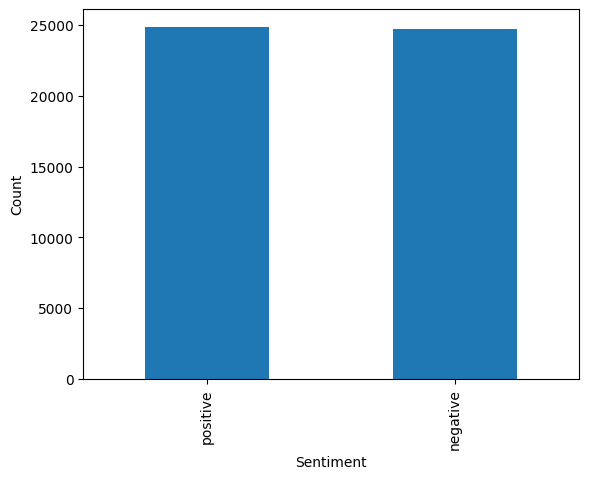

In [26]:
df["sentiment"].value_counts().plot(kind='bar')

df.title = "Distribution of Sentiment Labels"
plt.xlabel("Sentiment")
plt.ylabel("Count")